# **1. Pengenalan Dataset**

1. **Sumber Dataset**:  
    Dataset ini diperoleh dari *Kaggle*. Dataset ini bertemakan "Bank Transaction" diperoleh dari rekomendasi dataset Dicoding
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset ini tidak memiliki label atau kelas.
   - **Jumlah Baris**: Dataset ini memiliki lebih dari 2.500 baris
   - **Tipe Data**: Dataset ini mengandung data **kategorikal** dan **numerikal**.

# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# **3. Memuat Dataset**

In [2]:
df = pd.read_csv("Dataset_clustering.csv")
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


# **4. Exploratory Data Analysis**

1. Memahami Struktur Data

In [3]:
print(f"{df.shape[0]} baris dan {df.shape[1]}")

2512 baris dan 16


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

2. Menangani missing value dan duplikasi

In [5]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


In [6]:
df.isna().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

3. Analisis Distribusi, Korelasi, Visualisasi Data

In [7]:
# Mengategorikan kolom numerik
numerical_columns = ["TransactionAmount", "CustomerAge", "TransactionDuration",	"LoginAttempts", "AccountBalance"]

In [8]:
# Analisis deskriptif data numerik
df[numerical_columns].describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


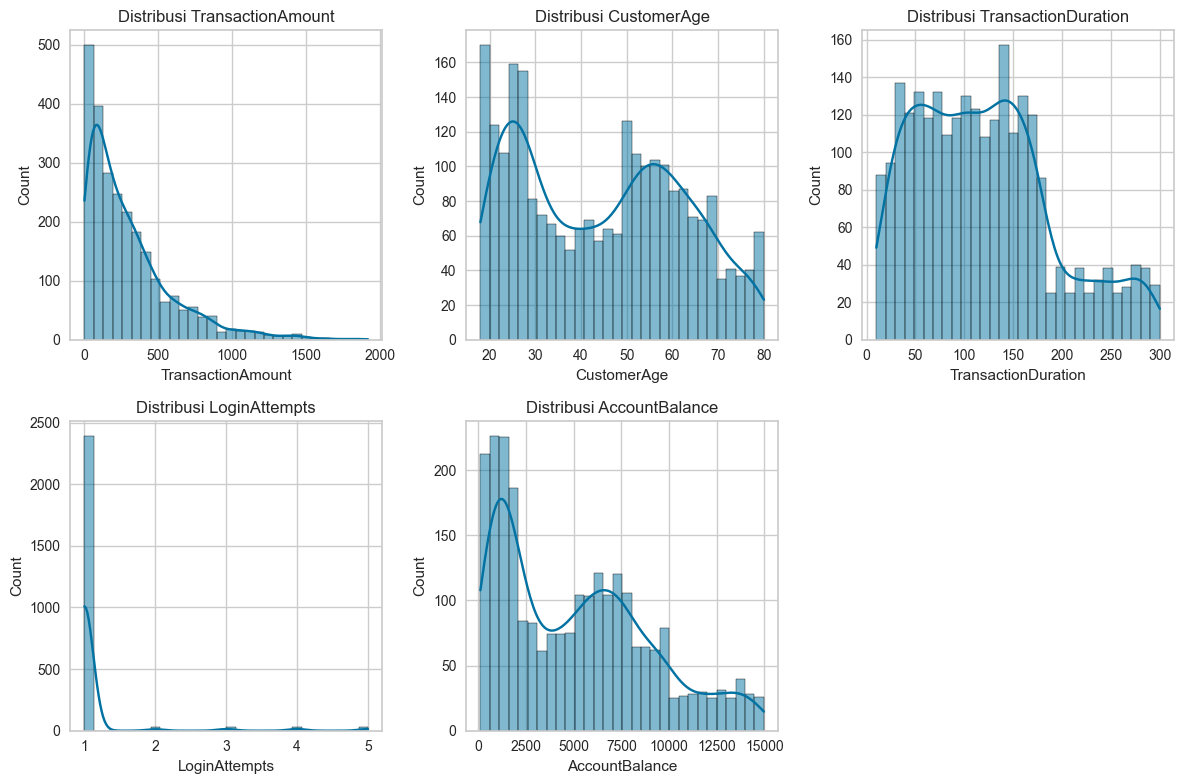

In [9]:
# Analisis distribusi data numerik
plt.figure(figsize=(12, 8))
for i, column in enumerate(numerical_columns):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[column], bins=30, kde=True)
    plt.title(f"Distribusi {column}")
plt.tight_layout()
plt.show()

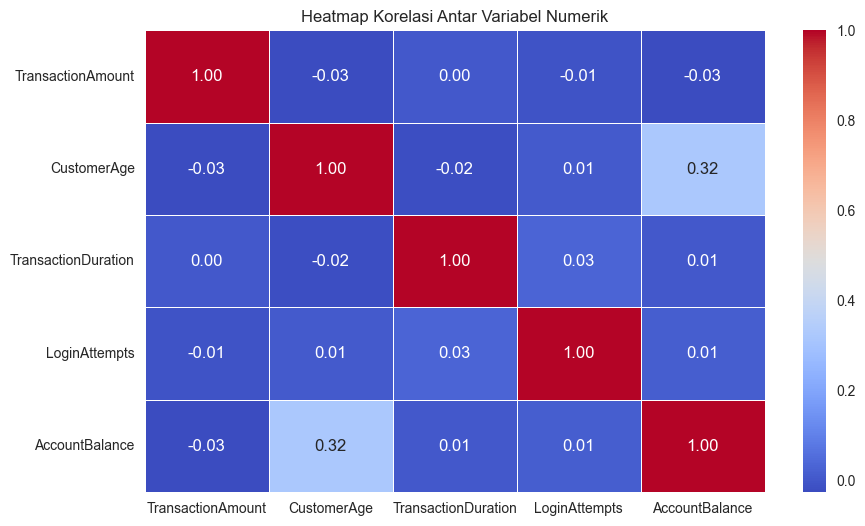

In [10]:
# Analisis heatmap korelasi
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Antar Variabel Numerik")
plt.show()

C:\Users\Rafif Idris Ardhana\AppData\Local\Temp\ipykernel_30240\3634594567.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Channel", palette="viridis")


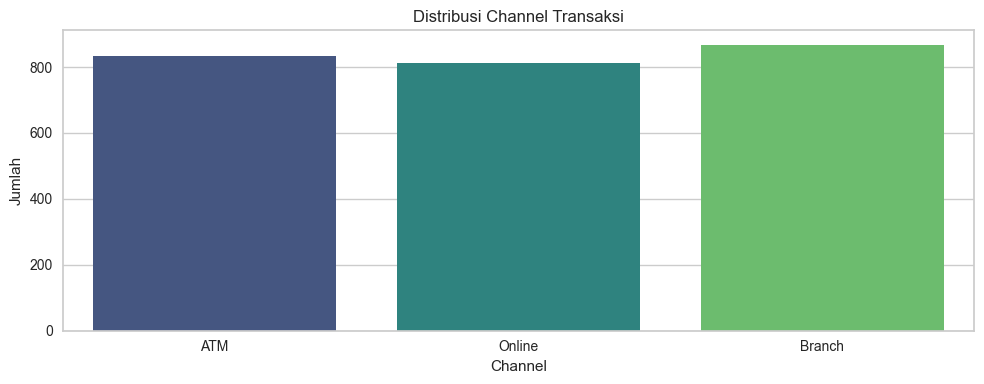

In [11]:
# Analisis kolom "Channel" yang digunakan pelanggan
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Channel", palette="viridis")
plt.title("Distribusi Channel Transaksi")
plt.xlabel("Channel")
plt.ylabel("Jumlah")

plt.tight_layout()
plt.show() 

# **5. Data Preprocessing**

In [12]:
# Fungsi untuk mendeteksi dan menangani outlier dengan metode IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Menerapkan metode IQR pada kolom numerik yang rentan terhadap outlier
columns_to_check = ["TransactionAmount", "TransactionDuration", "LoginAttempts", "AccountBalance"]
cleaned_df = df.copy()
for column in columns_to_check:
    cleaned_df = remove_outliers_iqr(cleaned_df, column)

# Menampilkan jumlah data sebelum dan sesudah menghapus outlier
df.shape[0], cleaned_df.shape[0]

(2512, 2282)

In [13]:
# Drop kolom yang tidak digunakan saat clustering
cleaned_df = cleaned_df.drop(columns=["TransactionID", "AccountID", "DeviceID", "IP Address", "MerchantID", "TransactionDate", "PreviousTransactionDate"])
cleaned_df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,Debit,San Diego,ATM,70,Doctor,81,1,5112.21
1,376.24,Debit,Houston,ATM,68,Doctor,141,1,13758.91
2,126.29,Debit,Mesa,Online,19,Student,56,1,1122.35
3,184.50,Debit,Raleigh,Online,26,Student,25,1,8569.06
4,13.45,Credit,Atlanta,Online,26,Student,198,1,7429.40


In [14]:
adjust_df = cleaned_df.copy()

In [15]:
# Inisialisasi Encoder
label_encoder = LabelEncoder()

# List kolom kategorikal
categorical_columns = adjust_df.select_dtypes(include="object")

# Encode kolom kategorikal
for column in categorical_columns:
    adjust_df[column] = label_encoder.fit_transform(adjust_df[column])

adjust_df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,1,36,0,70,0,81,1,5112.21
1,376.24,1,15,0,68,0,141,1,13758.91
2,126.29,1,23,2,19,3,56,1,1122.35
3,184.50,1,33,2,26,3,25,1,8569.06
4,13.45,0,1,2,26,3,198,1,7429.40


# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model**

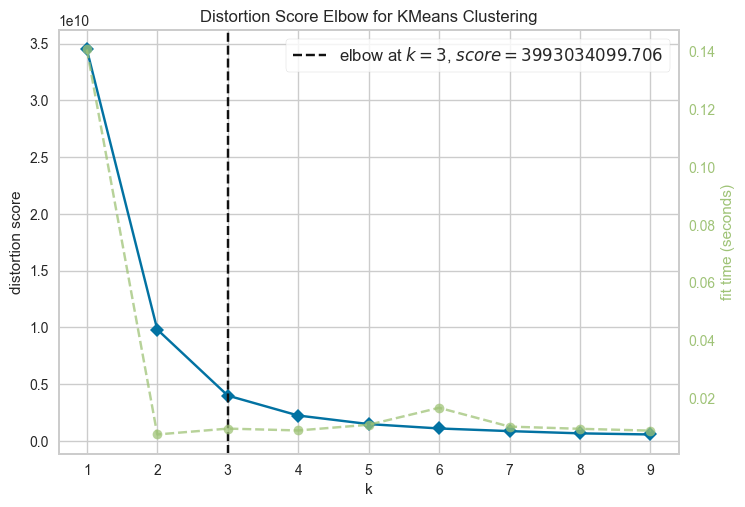

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [16]:
# Inisialisasi model KMeans tanpa parameter awal
kmeans = KMeans()
 
# Inisialisasi visualizer KElbow untuk menentukan jumlah cluster optimal
visualizer = KElbowVisualizer(kmeans, k=(1, 10))

# Fit visualizer dengan data untuk menemukan jumlah cluster optimal
visualizer.fit(adjust_df)

# Menampilkan grafik elbow untuk analisis
visualizer.show()

## **b. Evaluasi Model Clustering**

In [17]:
# Menerapkan model untuk menghitung sillhouette score
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(adjust_df)

# Menghitung Silhouette Score sebelum feature selection
silhouette = silhouette_score(adjust_df, labels)
print("Sillhoute score after feature selection: ", silhouette)

Sillhoute score after feature selection:  0.6282599567649727


## **c. Feature Selection**

In [18]:
adjust_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2282 entries, 0 to 2511
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionAmount    2282 non-null   float64
 1   TransactionType      2282 non-null   int64  
 2   Location             2282 non-null   int64  
 3   Channel              2282 non-null   int64  
 4   CustomerAge          2282 non-null   int64  
 5   CustomerOccupation   2282 non-null   int64  
 6   TransactionDuration  2282 non-null   int64  
 7   LoginAttempts        2282 non-null   int64  
 8   AccountBalance       2282 non-null   float64
dtypes: float64(2), int64(7)
memory usage: 178.3 KB


In [19]:
# Menyimpan hanya fitur yang terpilih untuk clustering
selected_features = ["TransactionAmount", "Channel", "CustomerAge", "TransactionDuration", "AccountBalance"]

selected_df = adjust_df[selected_features]

selected_df.head()

,TransactionAmount,Channel,CustomerAge,TransactionDuration,AccountBalance
0,14.09,0,70,81,5112.21
1,376.24,0,68,141,13758.91
2,126.29,2,19,56,1122.35
3,184.50,2,26,25,8569.06
4,13.45,2,26,198,7429.40


In [20]:
# Menjalankan K-Means clustering dengan 3 cluster
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
selected_df["Cluster"] = kmeans.fit_predict(selected_df)

# Menghitung Silhouette Score setelah feature selection
silhouette = silhouette_score(selected_df, selected_df["Cluster"])
print("Sillhoute score after feature selection: ", silhouette)

Sillhoute score after feature selection:  0.6284768790791548


C:\Users\Rafif Idris Ardhana\AppData\Local\Temp\ipykernel_30240\3124134020.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df["Cluster"] = kmeans.fit_predict(selected_df)


- Sillhouette score sebelum *feature selection* = 0.63
- Sillhouette score setelah *feature selection* = 0.63

## **d. Visualisasi Hasil CLustering**

C:\Users\Rafif Idris Ardhana\AppData\Local\Temp\ipykernel_30240\3011310951.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df['PCA1'] = pca_result[:, 0]
C:\Users\Rafif Idris Ardhana\AppData\Local\Temp\ipykernel_30240\3011310951.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df['PCA2'] = pca_result[:, 1]


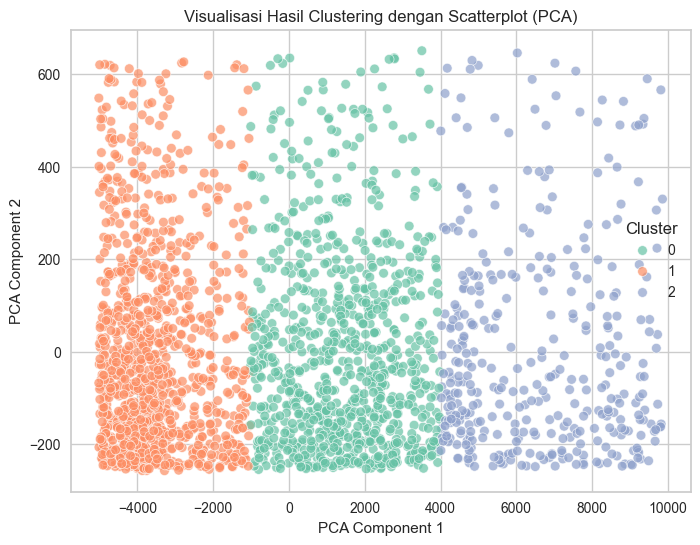

In [21]:
from sklearn.decomposition import PCA

# Menggunakan PCA untuk reduksi dimensi ke 2D
pca = PCA(n_components=2)
pca_result = pca.fit_transform(selected_df)
selected_df['PCA1'] = pca_result[:, 0]
selected_df['PCA2'] = pca_result[:, 1]

# Visualisasi scatter plot hasil clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=selected_df["PCA1"], y=selected_df["PCA2"], hue=selected_df["Cluster"], palette="Set2", alpha=0.7, edgecolors="w")
plt.title("Visualisasi Hasil Clustering dengan Scatterplot (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

## **e. Analisis dan Interpretasi Hasil Clustering**

In [22]:
inverse_df = selected_df.copy()
inverse_df.head()

,TransactionAmount,Channel,CustomerAge,TransactionDuration,AccountBalance,Cluster,PCA1,PCA2
0,14.09,0,70,81,5112.21,0,-7.109735,-241.381605
1,376.24,0,68,141,13758.91,2,8639.284228,127.045475
2,126.29,2,19,56,1122.35,1,-3997.113146,-132.012814
3,184.50,2,26,25,8569.06,0,3449.564752,-68.203443
4,13.45,2,26,198,7429.40,0,2309.969414,-240.527841


In [23]:
inverse_df.drop(columns=['PCA1', 'PCA2'], inplace=True)

In [24]:
label_encoder_channel = LabelEncoder()
label_encoder_channel.fit(cleaned_df["Channel"])
inverse_df["Channel"] = label_encoder_channel.inverse_transform(inverse_df["Channel"])

In [25]:
# Hasil clustering setelah di inverse
inverse_df.head(10)

,TransactionAmount,Channel,CustomerAge,TransactionDuration,AccountBalance,Cluster
0,14.09,ATM,70,81,5112.21,0
1,376.24,ATM,68,141,13758.91,2
2,126.29,Online,19,56,1122.35,1
3,184.50,Online,26,25,8569.06,0
4,13.45,Online,26,198,7429.40,0
5,92.15,ATM,18,172,781.68,1
6,7.08,ATM,37,139,13316.71,2
7,171.42,Branch,67,291,2796.24,1
8,106.23,Branch,51,86,9095.14,0
9,815.96,ATM,55,120,1021.88,1


In [26]:
# Menambahkan kolom TransactionType dan CustomerOccupation
inverse_df.insert(1, "TransactionType", cleaned_df["TransactionType"])
inverse_df.insert(5, "CustomerOccupation", cleaned_df["CustomerOccupation"])

# Cek hasil
inverse_df.head()

,TransactionAmount,TransactionType,Channel,CustomerAge,TransactionDuration,CustomerOccupation,AccountBalance,Cluster
0,14.09,Debit,ATM,70,81,Doctor,5112.21,0
1,376.24,Debit,ATM,68,141,Doctor,13758.91,2
2,126.29,Debit,Online,19,56,Student,1122.35,1
3,184.50,Debit,Online,26,25,Student,8569.06,0
4,13.45,Credit,Online,26,198,Student,7429.40,0


In [27]:
inverse_df.to_csv("Dataset_inisiasi.csv", index=False)

In [28]:
# Hitung statistik rata-rata per cluster
cluster_summary = inverse_df.select_dtypes(include=["number"]).groupby("Cluster").agg(["mean"])
cluster_summary.head()

,TransactionAmount,CustomerAge,TransactionDuration,AccountBalance
,mean,mean,mean,mean
Cluster,,,,
0,252.128958,51.560137,117.410080,6571.645017
1,257.450528,37.864553,120.525456,1592.656503
2,258.138125,47.654891,118.288043,11651.662772


In [29]:
# Melihat modus produk per cluster
cluster_summary_cat = inverse_df.groupby("Cluster")["Channel"].agg(lambda x: x.mode()[0]).reset_index()
cluster_summary_cat.head()

,Cluster,Channel
0,0,Branch
1,1,ATM
2,2,Branch


# Analisis Karakteristik Cluster dari Model KMeans

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

## Cluster 0 (Medium Spender):
- **Rata-rata Jumlah Transaksi:** 252.13
- **Rata-rata Usia Pelanggan:** 52 Tahun
- **Rata-rata Durasi Transaksi:** 117 detik
- **Rata-rata Saldo:** 6,571.65
- **Analisis:** Cluster ini sebagian besar adalah pelanggan dengan pengeluaran sedang dan cenderung lebih tua. Mereka lebih nyaman bertransaksi dengan datang langsung ke bank serta memiliki keputusan yang lebih cepat saat bertransaksi. Pelanggan pada cluster ini memiliki saldo yang cukup stabil.

## Cluster 1 (Low Spender):
- **Rata-rata Jumlah Transaksi:** 257.45
- **Rata-rata Usia Pelanggan:** 38 Tahun
- **Rata-rata Durasi Transaksi:** 121 detik
- **Rata-rata Saldo:** 1,592.66  
- **Analisis:** Cluster ini adalah pelanggan dengan daya beli rendah yang diindikasi oleh rata-rata saldo yang kecil. Pelanggan ini didominasi oleh pelanggan muda. Mereka cenderung melakukan transaksi di ATM dan mungkin termasuk pelanggan baru yang masih beradaptasi dengan layanan dan berhati-hati dalam mengambil keputusan dalam bertransaksi, disebabkan oleh rata-rata durasi transaksi yang lebih lama. 

## Cluster 2 (High Spender):
- **Rata-rata Jumlah Transaksi:** 258.13
- **Rata-rata Usia Pelanggan:** 48 Tahun
- **Rata-rata Durasi Transakis:** 118 detik
- **Rata-rata Saldo:** 11,651.66     
- **Analisis:** Cluster ini sebagian besar adalah pelanggan dengan daya beli tinggi yang rata-rata umurnya berada di antara cluster 0 dan cluster 1. Sebagian besar dari mereka, lebih nyaman bertransaksi dengan datang ke bank. Rata-rata saldo paling besar mengindikasikan bahwa mereka memiliki lebih banyak uang untuk dikeluarkan/dibelanjakan, dengan durasi transaksi yang cukup cepat menandakan bahwa mereka cenderung lebih percaya diri dalam pengambilan keputusan untuk bertransaksi.

# Interpretasi Bisnis Hasil Clustering

## Logika Bisnis:
Secara logis pelanggan dengan saldo lebih besar cenderung lebih sering melakukan transaksi atau memiliki daya beli lebih tinggi. Pelanggan yang lebih muda cenderung memiliki saldo yang lebih rendah. Perbedaan jumlah transaksi per cluster tidak terlalu ekstrem, menandakan habits transaksi antar cluster tidak terlalu berbeda

## Analisis Pemanfaatan Pola Cluster:
- Cluster 2 merupakan High Spender, perlu melakukan pertimbangan untuk menjaga loyalitas pelanggan dengan membuat layanan eksklusif seperti layanan khusus VIP, promo spesial, serta diskon eksklusif.
- Cluster 1 merupakan Low Spender, perlu mempertimbangkan engagement pelanggan dan edukasi layanan. Hal ini dapat didukung dengan mengadakan diskon serta cashback bagi para pelanggan serta membangun kebiasaan transaksi dengan konten edukasi layanan.
- Cluster 0 merupakan Medium Spender, perlu mempertahankan pelanggan dengan menawarkan loyalty program untuk meningkatkan transaksi mereka menjadi lebih tinggi. 